# 2.1 Sensitivity maps

Part 2's running model is the **Budyko–Sellers energy balance model**
{cite}`budyko1969effect,sellers1969global`: the Chapter 1.3 model extended over
latitude. Zonal-mean surface temperature $T(x, t)$ evolves on an equal-area grid in
$x = \sin(\mathrm{latitude})$ according to

$$C\,\frac{\partial T}{\partial t}
= \underbrace{Q\, s(x)\,\bigl(1 - \alpha(T)\bigr)}_{\text{absorbed sunlight}}
\;-\; \underbrace{(A + B\,T)}_{\text{outgoing longwave}}
\;+\; \underbrace{D\,\frac{\partial}{\partial x}\Bigl[(1 - x^2)\,\frac{\partial T}{\partial x}\Bigr]}_{\text{poleward heat transport}} .$$

Three ingredients are new. Insolation varies with latitude through the shape function
$s(x)$; outgoing longwave radiation is linearized about 0 °C, with $A$ and $B$ from
Budyko's fits to observations; and heat moves poleward by diffusion with coefficient
$D$ — a deliberately crude stand-in for everything the atmosphere and ocean do to carry
energy toward the poles. The temperature-dependent albedo now creates an **ice line**:
latitudes colder than −10 °C brighten. The model is non-chaotic (perturbations decay),
so every gradient in Part 2 is well behaved even through long integrations — by
construction, not by luck.

This chapter builds the model and asks its first science question: **to which local
perturbations is the Arctic most sensitive?** One reverse-mode pass returns the answer
at every latitude simultaneously — an *adjoint sensitivity map*.

```{admonition} Learning goals
:class: tip
- Implement the Budyko–Sellers model in JAX as a step function plus `lax.scan`
- Validate its climatology against the observed ice edge and equator-pole contrast
- Compute an adjoint sensitivity map — one diagnostic, all inputs — in a single pass
- Reproduce the map with `vmap`-ed finite differences, and compare cost and accuracy
```

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)   # climate work needs double precision
# Running on Colab? First run:  %pip install -q optax equinox diffrax

In [2]:
# --- The Budyko-Sellers model (defined in Chapter 2.1; repeated so this notebook is self-contained)
N_LAT = 60
x_edge = jnp.linspace(-1.0, 1.0, N_LAT + 1)      # cell edges in x = sin(latitude)
x = 0.5 * (x_edge[:-1] + x_edge[1:])             # cell centres (an equal-area grid)
dx = 2.0 / N_LAT
lat = jnp.rad2deg(jnp.arcsin(x))                 # centre latitudes (degrees)

Q = 340.25              # global-mean insolation S0/4, W m^-2
s_x = 1.0 - 0.482 * 0.5 * (3.0 * x**2 - 1.0)     # annual-mean insolation shape s(x)
A_olr = 203.3           # outgoing longwave radiation at 0 degC, W m^-2
B_olr = 2.09            # longwave feedback, W m^-2 K^-1
heat_capacity = 4.0e7   # J m^-2 K^-1 (~10 m of water)
dt = 21600.0            # 6-hour time step, s

default_params = {"D": 0.48, "albedo_warm": 0.32, "albedo_ice": 0.62}

def albedo(T, p):
    ice_fraction = 0.5 * (1.0 - jnp.tanh((T + 10.0) / 2.0))    # ice below about -10 degC
    return p["albedo_warm"] + (p["albedo_ice"] - p["albedo_warm"]) * ice_fraction

def energy_tendency(T, p, forcing=0.0):
    """Net energy input at each latitude (W m^-2), for temperature T in degC."""
    absorbed = Q * s_x * (1.0 - albedo(T, p))
    emitted = A_olr + B_olr * T
    flux = p["D"] * (1.0 - x_edge[1:-1] ** 2) * jnp.diff(T) / dx   # poleward heat flux
    flux = jnp.concatenate([jnp.zeros(1), flux, jnp.zeros(1)])     # no flux through the poles
    transport = jnp.diff(flux) / dx
    return absorbed - emitted + transport + forcing

def integrate(T0, p, forcing=0.0, n_years=30):
    """Step the model forward and return the final temperature profile."""
    n_steps = int(n_years * 365.25 * 86400 / dt)
    def step(T, _):
        return T + dt / heat_capacity * energy_tendency(T, p, forcing), None
    T_final, _ = jax.lax.scan(step, T0, None, length=n_steps)
    return T_final

T_start = 15.0 - 25.0 * 0.5 * (3.0 * x**2 - 1.0)    # smooth warm initial profile

A note on organization: every Part 2 chapter repeats this model-definition cell
verbatim rather than importing it from a shared file, so that each notebook runs
standalone (including on Colab, which downloads one notebook at a time). In a research
project the model would live in a module.

## The simulated climate

Thirty years of spin-up reaches equilibrium (the model's slowest adjustment timescale,
set by $C/B$, is under a year). The resulting climate is worth a hard look before any
gradients — a sensitivity map of a bad climate is a bad sensitivity map:

global-mean temperature:  11.2 degC   (observed ~14)
equator temperature:      23.9 degC   (observed ~26)
polar temperature:       -16.5 degC
ice edge at |latitude| = 72 deg    (observed ~72)


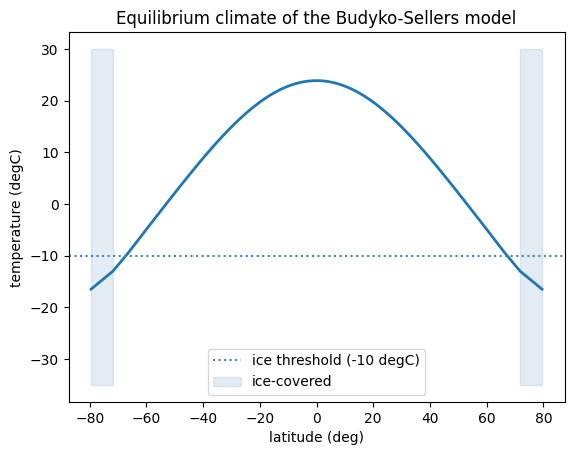

In [3]:
T_eq = jax.jit(integrate, static_argnames="n_years")(T_start, default_params)

ice = T_eq < -10.0
ice_edge = float(jnp.min(jnp.abs(lat[ice])))
print(f"global-mean temperature: {float(jnp.mean(T_eq)):5.1f} degC   (observed ~14)")
print(f"equator temperature:     {float(T_eq[N_LAT//2]):5.1f} degC   (observed ~26)")
print(f"polar temperature:       {float(T_eq[-1]):5.1f} degC")
print(f"ice edge at |latitude| = {ice_edge:.0f} deg    (observed ~72)")

plt.plot(lat, T_eq, lw=2)
plt.axhline(-10, color="steelblue", ls=":", label="ice threshold (-10 degC)")
plt.fill_between(lat, -35, 30, where=ice, alpha=0.15, color="steelblue", label="ice-covered")
plt.xlabel("latitude (deg)"); plt.ylabel("temperature (degC)")
plt.legend(); plt.title("Equilibrium climate of the Budyko-Sellers model")
plt.show()

The mean over `x` is already an area-weighted global mean — that is why the model
uses the $\sin(\mathrm{latitude})$ grid. The climate is structurally right (a slightly
cool global mean, a realistic equator–pole contrast of about 40 K, polar ice caps
reaching to 72°), which is as much as a two-parameter-albedo annual-mean model should
claim.

## One adjoint pass, one map

The science question: *if a 1 W m⁻² heating were applied at a single latitude — by an
aerosol change, a cloud feedback, a sea-ice anomaly — how much would the Arctic warm?*
Define the diagnostic (area-mean temperature poleward of 60° N) as a function of a
per-latitude forcing field, and take its gradient. Because the diagnostic is one number
and the forcing has 60 components, this is exactly the case reverse mode prices at a
single pass:

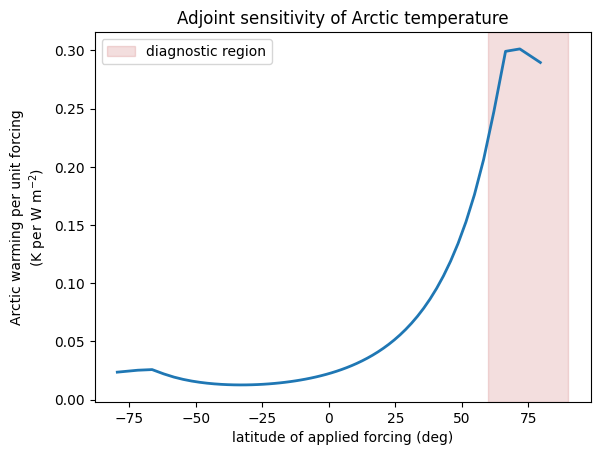

In [4]:
arctic = jnp.where(x > jnp.sin(jnp.deg2rad(60.0)), 1.0, 0.0)

def arctic_mean_T(forcing):
    T = integrate(T_start, default_params, forcing)
    return jnp.sum(T * arctic) / jnp.sum(arctic)

sensitivity_map = jax.jit(jax.grad(arctic_mean_T))(jnp.zeros(N_LAT))

plt.plot(lat, sensitivity_map, lw=2)
plt.axvspan(60, 90, alpha=0.15, color="firebrick", label="diagnostic region")
plt.xlabel("latitude of applied forcing (deg)")
plt.ylabel("Arctic warming per unit forcing\n(K per W m$^{-2}$)")
plt.legend(); plt.title("Adjoint sensitivity of Arctic temperature")
plt.show()

Reading the map as science: forcing applied *inside* the Arctic is most effective
(about 0.3 K per W m⁻², amplified by the ice–albedo feedback as warming darkens the
surface), but the sensitivity is nowhere zero — heating at 45° N still warms the Arctic
at roughly a third of that rate, delivered by the diffusive transport, and even
tropical and Southern-Hemisphere forcing leaks through. The equivalent information from
forward calculations would require one perturbed model run per latitude. This is the
workflow of classical adjoint sensitivity studies {cite}`errico1997adjoint` — with the
adjoint generated by `jax.grad` instead of years of hand coding.

## The brute-force check

Skepticism is warranted for any quantity produced by one pass of anything. The
finite-difference version of the map perturbs one latitude at a time — 60 pairs of
model runs, batched by `vmap` into a single vectorized computation:

In [5]:
import time

@jax.jit
def fd_sensitivity(i, h=0.01):
    bump = jnp.zeros(N_LAT).at[i].set(h)
    return (arctic_mean_T(bump) - arctic_mean_T(-bump)) / (2 * h)

grad_fn = jax.jit(jax.grad(arctic_mean_T))
grad_fn(jnp.zeros(N_LAT)).block_until_ready()          # compile before timing
t = time.perf_counter()
adjoint_map = grad_fn(jnp.zeros(N_LAT)).block_until_ready()
t_adj = time.perf_counter() - t

fd_map = jax.vmap(fd_sensitivity)(jnp.arange(N_LAT))   # compile
t = time.perf_counter()
fd_map = jax.vmap(fd_sensitivity)(jnp.arange(N_LAT)).block_until_ready()
t_fd = time.perf_counter() - t

print(f"adjoint map:          {t_adj:6.3f} s  (one reverse pass)")
print(f"finite differences:   {t_fd:6.3f} s  (120 model runs)")
print(f"largest disagreement: {float(jnp.max(jnp.abs(adjoint_map - fd_map))):.2e} K per W m^-2")

adjoint map:           0.035 s  (one reverse pass)
finite differences:    4.452 s  (120 model runs)
largest disagreement: 4.18e-07 K per W m^-2


The two maps agree to about seven decimal digits; the small residual is the finite
difference's own truncation error, not the adjoint's. The cost ratio — two orders of
magnitude on this small problem — is set by the number of inputs — for a model with a million-component forcing
field it would be roughly a million to one, which is why adjoint maps changed what
counts as an askable question.

**Exercises.**
1. Compute the sensitivity of the *ice-edge latitude* to forcing at every latitude.
   (Hint: a differentiable proxy for the ice edge is the area-mean of
   `jax.nn.sigmoid((-10 - T) / 2)`, the ice-covered fraction.)
2. Map the sensitivity of *global*-mean temperature to forcing. Why is it nearly flat
   at low latitudes, and what does its polar structure say about feedbacks?
3. Rebuild the map with the diagnostic poleward of 80° N. Does the mid-latitude
   contribution shrink or grow? Explain via the transport term.